## Cài đặt thư viện cho môi trường

In [1]:
!pip install -r requirements.txt

## Thêm thư viện

In [2]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

## Lấy dữ liệu từ Boston

In [3]:
df = pd.read_csv("BostonHousing.csv")

In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [10]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

# Data Preparation

In [11]:
x = df.drop("medv",axis=1)

y = df['medv']

In [12]:
x

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [13]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 501, dtype: float64

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=48)

In [15]:
print(x.shape)
print(x_train.shape)
print(x_test.shape)

(501, 13)
(400, 13)
(101, 13)


In [16]:
ss = StandardScaler()

x_train = ss.fit_transform(x_train)
x_test  = ss.transform(x_test)

In [17]:
x_train

array([[-0.40188815, -0.50258597, -0.99674546, ..., -0.84931257,
         0.42473226, -0.86733813],
       [-0.39058237,  0.54088121, -0.83743907, ...,  0.58412636,
         0.41940809,  0.1136017 ],
       [-0.40459359,  3.46258933, -1.37731075, ..., -0.66435271,
         0.43885764, -1.11471801],
       ...,
       [-0.40536895, -0.50258597, -1.31535826, ..., -1.17299233,
         0.36344988, -0.52987195],
       [-0.40241615,  0.37392647, -0.76221105, ..., -0.75683264,
         0.43885764, -0.56133067],
       [-0.40758801,  0.2487104 , -1.25340577, ..., -1.45043212,
         0.43885764, -1.05466046]])

In [18]:
x_test

array([[ 0.17415952, -0.50258597,  1.07571276, ...,  0.81532619,
         0.2065496 , -1.30061039],
       [ 0.19698632, -0.50258597,  1.07571276, ...,  0.81532619,
         0.31053407,  0.70273757],
       [-0.39998899, -0.50258597, -0.99674546, ..., -0.84931257,
         0.39898062, -0.3211005 ],
       ...,
       [-0.3985108 , -0.50258597,  0.459138  , ..., -1.12675236,
         0.43885764, -0.53988154],
       [-0.36997106, -0.50258597,  1.63476021, ...,  1.27772585,
         0.23621288,  0.64982974],
       [ 2.49258497, -0.50258597,  1.07571276, ...,  0.81532619,
         0.43885764,  2.27710311]])

# Model Training

# Linear Regression

In [ ]:
from catboost import CatBoostRegressor

lr = CatBoostRegressor()

param_dist = {
    'depth': [4, 6, 8], # Độ sâu của cây (càng lớn mô hình càng phức tạp, dễ overfit)
    'learning_rate': [0.1, 0.01, 0.001], # Tốc độ học (nhỏ thì học chậm nhưng ổn hơn)
    'l2_leaf_reg': [1, 3, 5, 7], # Giảm overfit cho lá cây
    'bagging_temperature': [0.5, 1, 1.5], # Mức độ ngẫu nhiên khi lấy mẫu (bagging)
    'random_strength': [0.5, 1, 1.5], # Độ ngẫu nhiên khi chia cây, giảm overfit
    'border_count': [32, 64, 128], # Phân nhỏ dữ liệu liên tục
    'iterations': [100, 200, 300], # Số lượng cây (nhiều giúp mô hình mạnh hơn)
}

random_search = RandomizedSearchCV(lr, param_distributions=param_dist, n_iter=20, cv=5)

In [20]:
random_search.fit(x_train,y_train)

0:	learn: 9.0595819	total: 135ms	remaining: 26.8s
1:	learn: 9.0533567	total: 136ms	remaining: 13.5s
2:	learn: 9.0485793	total: 137ms	remaining: 9.02s
3:	learn: 9.0433971	total: 139ms	remaining: 6.79s
4:	learn: 9.0376061	total: 140ms	remaining: 5.44s
5:	learn: 9.0321841	total: 141ms	remaining: 4.55s
6:	learn: 9.0270130	total: 142ms	remaining: 3.91s
7:	learn: 9.0216431	total: 143ms	remaining: 3.43s
8:	learn: 9.0163769	total: 145ms	remaining: 3.07s
9:	learn: 9.0104589	total: 147ms	remaining: 2.79s
10:	learn: 9.0056588	total: 148ms	remaining: 2.54s
11:	learn: 9.0006826	total: 151ms	remaining: 2.36s
12:	learn: 8.9954433	total: 152ms	remaining: 2.19s
13:	learn: 8.9898254	total: 153ms	remaining: 2.04s
14:	learn: 8.9840820	total: 154ms	remaining: 1.9s
15:	learn: 8.9781902	total: 155ms	remaining: 1.79s
16:	learn: 8.9725833	total: 157ms	remaining: 1.69s
17:	learn: 8.9670176	total: 159ms	remaining: 1.6s
18:	learn: 8.9617021	total: 160ms	remaining: 1.53s
19:	learn: 8.9566382	total: 162ms	remaining

,estimator,CatBoostRegre...nction='RMSE')
,param_distributions,"{'bagging_temperature': [0.5, 1, ...], 'border_count': [32, 64, ...], 'depth': [4, 6, ...], 'iterations': [100, 200, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [21]:
y_pred = random_search.predict(x_test)

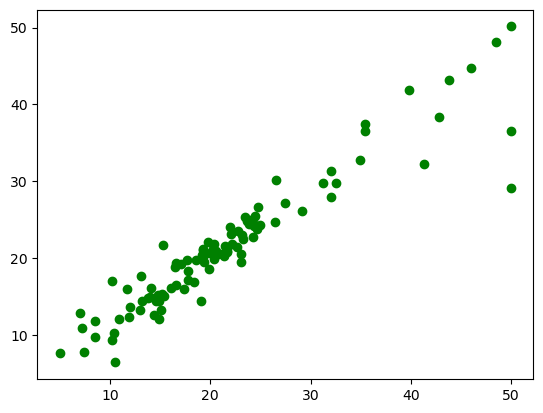

In [22]:
plt.scatter(y_test, y_pred, color ="green")

In [23]:
r2_score(y_test,y_pred)

0.8841837930475587

# Pickling the Files

In [24]:
import pickle as pkl

pkl.dump(random_search,open('housepred.pkl','wb'))

pkl.dump(ss,open('scaler.pkl','wb'))